## Análisis del Mercado Laboral de Analistas de Datos

## IMPORTACIÓN DE LIBRERÍAS

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


## CARGA DEL DATASET

In [3]:
df = pd.read_csv("../data/analisis_mercado.csv")
df.head()

,ID,Empresa,País,Nivel,Salario,Python,SQL,Excel,PowerBI,Tableau,R
0,1,VisionAnalytics,España,Mid,43819,No,Sí,Sí,Sí,Sí,No
1,2,VisionAnalytics,Argentina,Mid,44041,Sí,Sí,Sí,Sí,Sí,Sí
2,3,BusinessData,México,Junior,39654,Sí,Sí,No,No,Sí,No
3,4,InsightTech,Brasil,Junior,35514,Sí,Sí,Sí,Sí,Sí,No
4,5,MarketData,España,Mid,55403,Sí,Sí,Sí,No,No,No


## EXPLORACIÓN INICIAL

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   ID       500 non-null    int64
 1   Empresa  500 non-null    str  
 2   País     500 non-null    str  
 3   Nivel    500 non-null    str  
 4   Salario  500 non-null    int64
 5   Python   500 non-null    str  
 6   SQL      500 non-null    str  
 7   Excel    500 non-null    str  
 8   PowerBI  500 non-null    str  
 9   Tableau  500 non-null    str  
 10  R        500 non-null    str  
dtypes: int64(2), str(9)
memory usage: 43.1 KB


In [4]:
df.describe()

,ID,Salario
count,500.000000,500.000000
mean,250.500000,53202.956000
std,144.481833,21734.035897
min,1.000000,30006.000000
25%,125.750000,36275.750000
50%,250.500000,45257.000000
75%,375.250000,61775.500000
max,500.000000,109994.000000


In [5]:
df.columns

Index(['ID', 'Empresa', 'País', 'Nivel', 'Salario', 'Python', 'SQL', 'Excel',
       'PowerBI', 'Tableau', 'R'],
      dtype='str')

## LIMPIEZA DE DATOS

In [6]:
# Valores faltantes
df.isnull().sum()

ID         0
Empresa    0
País       0
Nivel      0
Salario    0
Python     0
SQL        0
Excel      0
PowerBI    0
Tableau    0
R          0
dtype: int64

In [7]:
# Eliminar duplicados
df = df.drop_duplicates()

In [8]:
# Revisar valores únicos
df["Nivel"].unique()

<StringArray>
['Mid', 'Junior', 'Senior']
Length: 3, dtype: str

In [9]:
# Corregir formato
df["Nivel"] = df["Nivel"].str.capitalize()

In [10]:
# Verificar herramientas
tools = ["Python", "SQL", "Excel", "PowerBI", "Tableau", "R"]
for col in tools:
    print(col, df[col].unique())

Python <StringArray>
['No', 'Sí']
Length: 2, dtype: str
SQL <StringArray>
['Sí']
Length: 1, dtype: str
Excel <StringArray>
['Sí', 'No']
Length: 2, dtype: str
PowerBI <StringArray>
['Sí', 'No']
Length: 2, dtype: str
Tableau <StringArray>
['Sí', 'No']
Length: 2, dtype: str
R <StringArray>
['No', 'Sí']
Length: 2, dtype: str


## ANÁLISIS EXPLORATORIO (EDA)

In [11]:
#Distribución de niveles
df["Nivel"].value_counts()

Nivel
Junior    239
Mid       159
Senior    102
Name: count, dtype: int64

In [12]:
#Herrramientas mas solicitadas
df[tools].apply(lambda x: (x == "Sí").sum())

Python     301
SQL        500
Excel      406
PowerBI    288
Tableau    189
R          119
dtype: int64

In [13]:
#Herramientas por nivel
table = pd.crosstab(df["Nivel"], df["Python"])
print(table)

Python  No   Sí
Nivel          
Junior  90  149
Mid     68   91
Senior  41   61


In [14]:
#Salario Promedio
df.groupby("Nivel")["Salario"].mean()

Nivel
Junior    36035.414226
Mid       54981.402516
Senior    90656.578431
Name: Salario, dtype: float64

## VISUALIZACIONES


<function matplotlib.pyplot.show(close=None, block=None)>

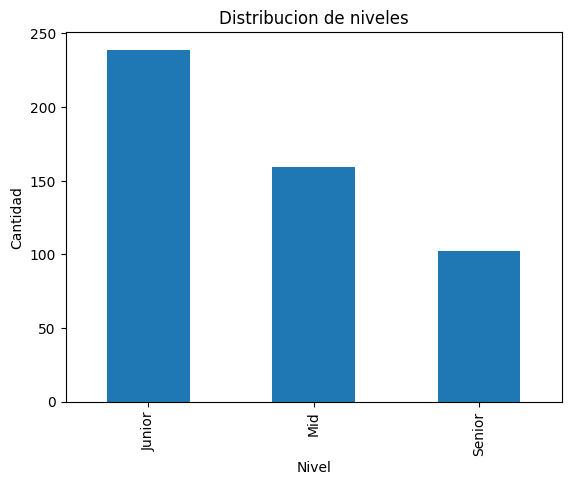

In [15]:
#Distribución de niveles
df["Nivel"].value_counts().plot(kind="bar")
plt.title("Distribucion de niveles")
plt.xlabel("Nivel")
plt.ylabel("Cantidad")
plt.show

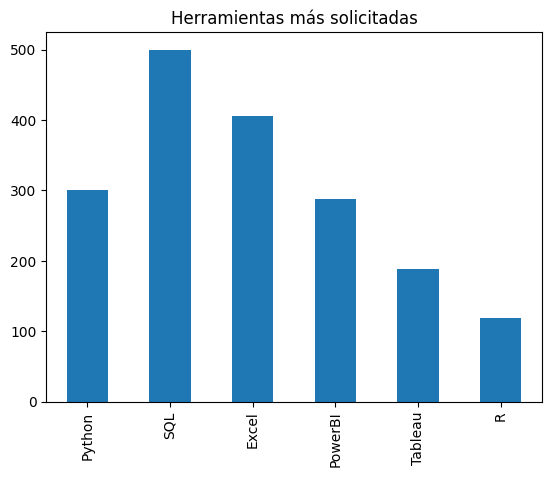

In [16]:
#Herramientas más solicitadas
df[tools].apply(lambda x: (x=="Sí").sum()).plot(kind="bar")
plt.title("Herramientas más solicitadas")
plt.show()

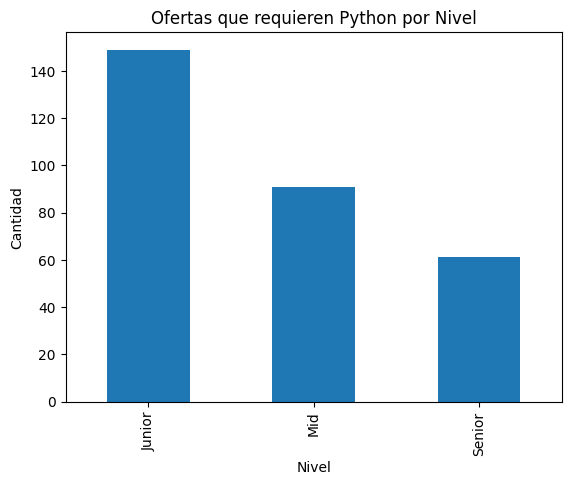

In [ ]:
#Oferta que requieren Python por Nivel
table["Sí"].plot(kind="bar")

plt.title("Ofertas que requieren Python por Nivel")
plt.xlabel("Nivel")
plt.ylabel("Cantidad")

plt.show()

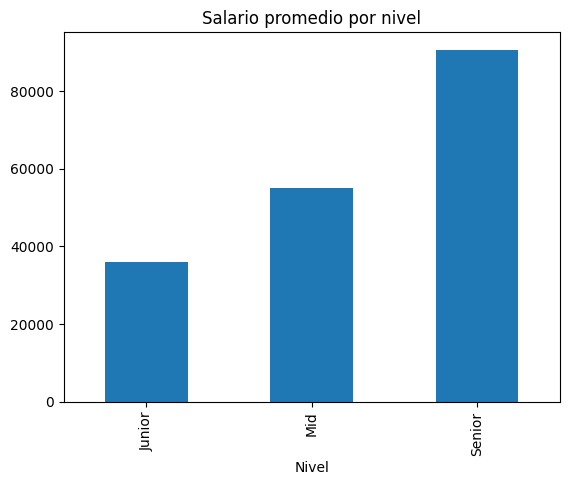

In [18]:
#Salario promedio
df.groupby("Nivel")["Salario"].mean().plot(kind="bar")
plt.title("Salario promedio por nivel")
plt.show()

In [4]:
conteo_paises = df['País'].value_counts()

porcentaje_paises = df['País'].value_counts(normalize=True) * 100

# Muestra los resultados en una tabla limpia
tabla_distribucion = pd.DataFrame({
    'Total Ofertas': conteo_paises,
    'Porcentaje (%)': porcentaje_paises.round(2)
})
tabla_distribucion

,Total Ofertas,Porcentaje (%)
País,,
España,73,14.6
México,72,14.4
Brasil,71,14.2
Perú,67,13.4
USA,62,12.4
Chile,60,12.0
Colombia,51,10.2
Argentina,44,8.8


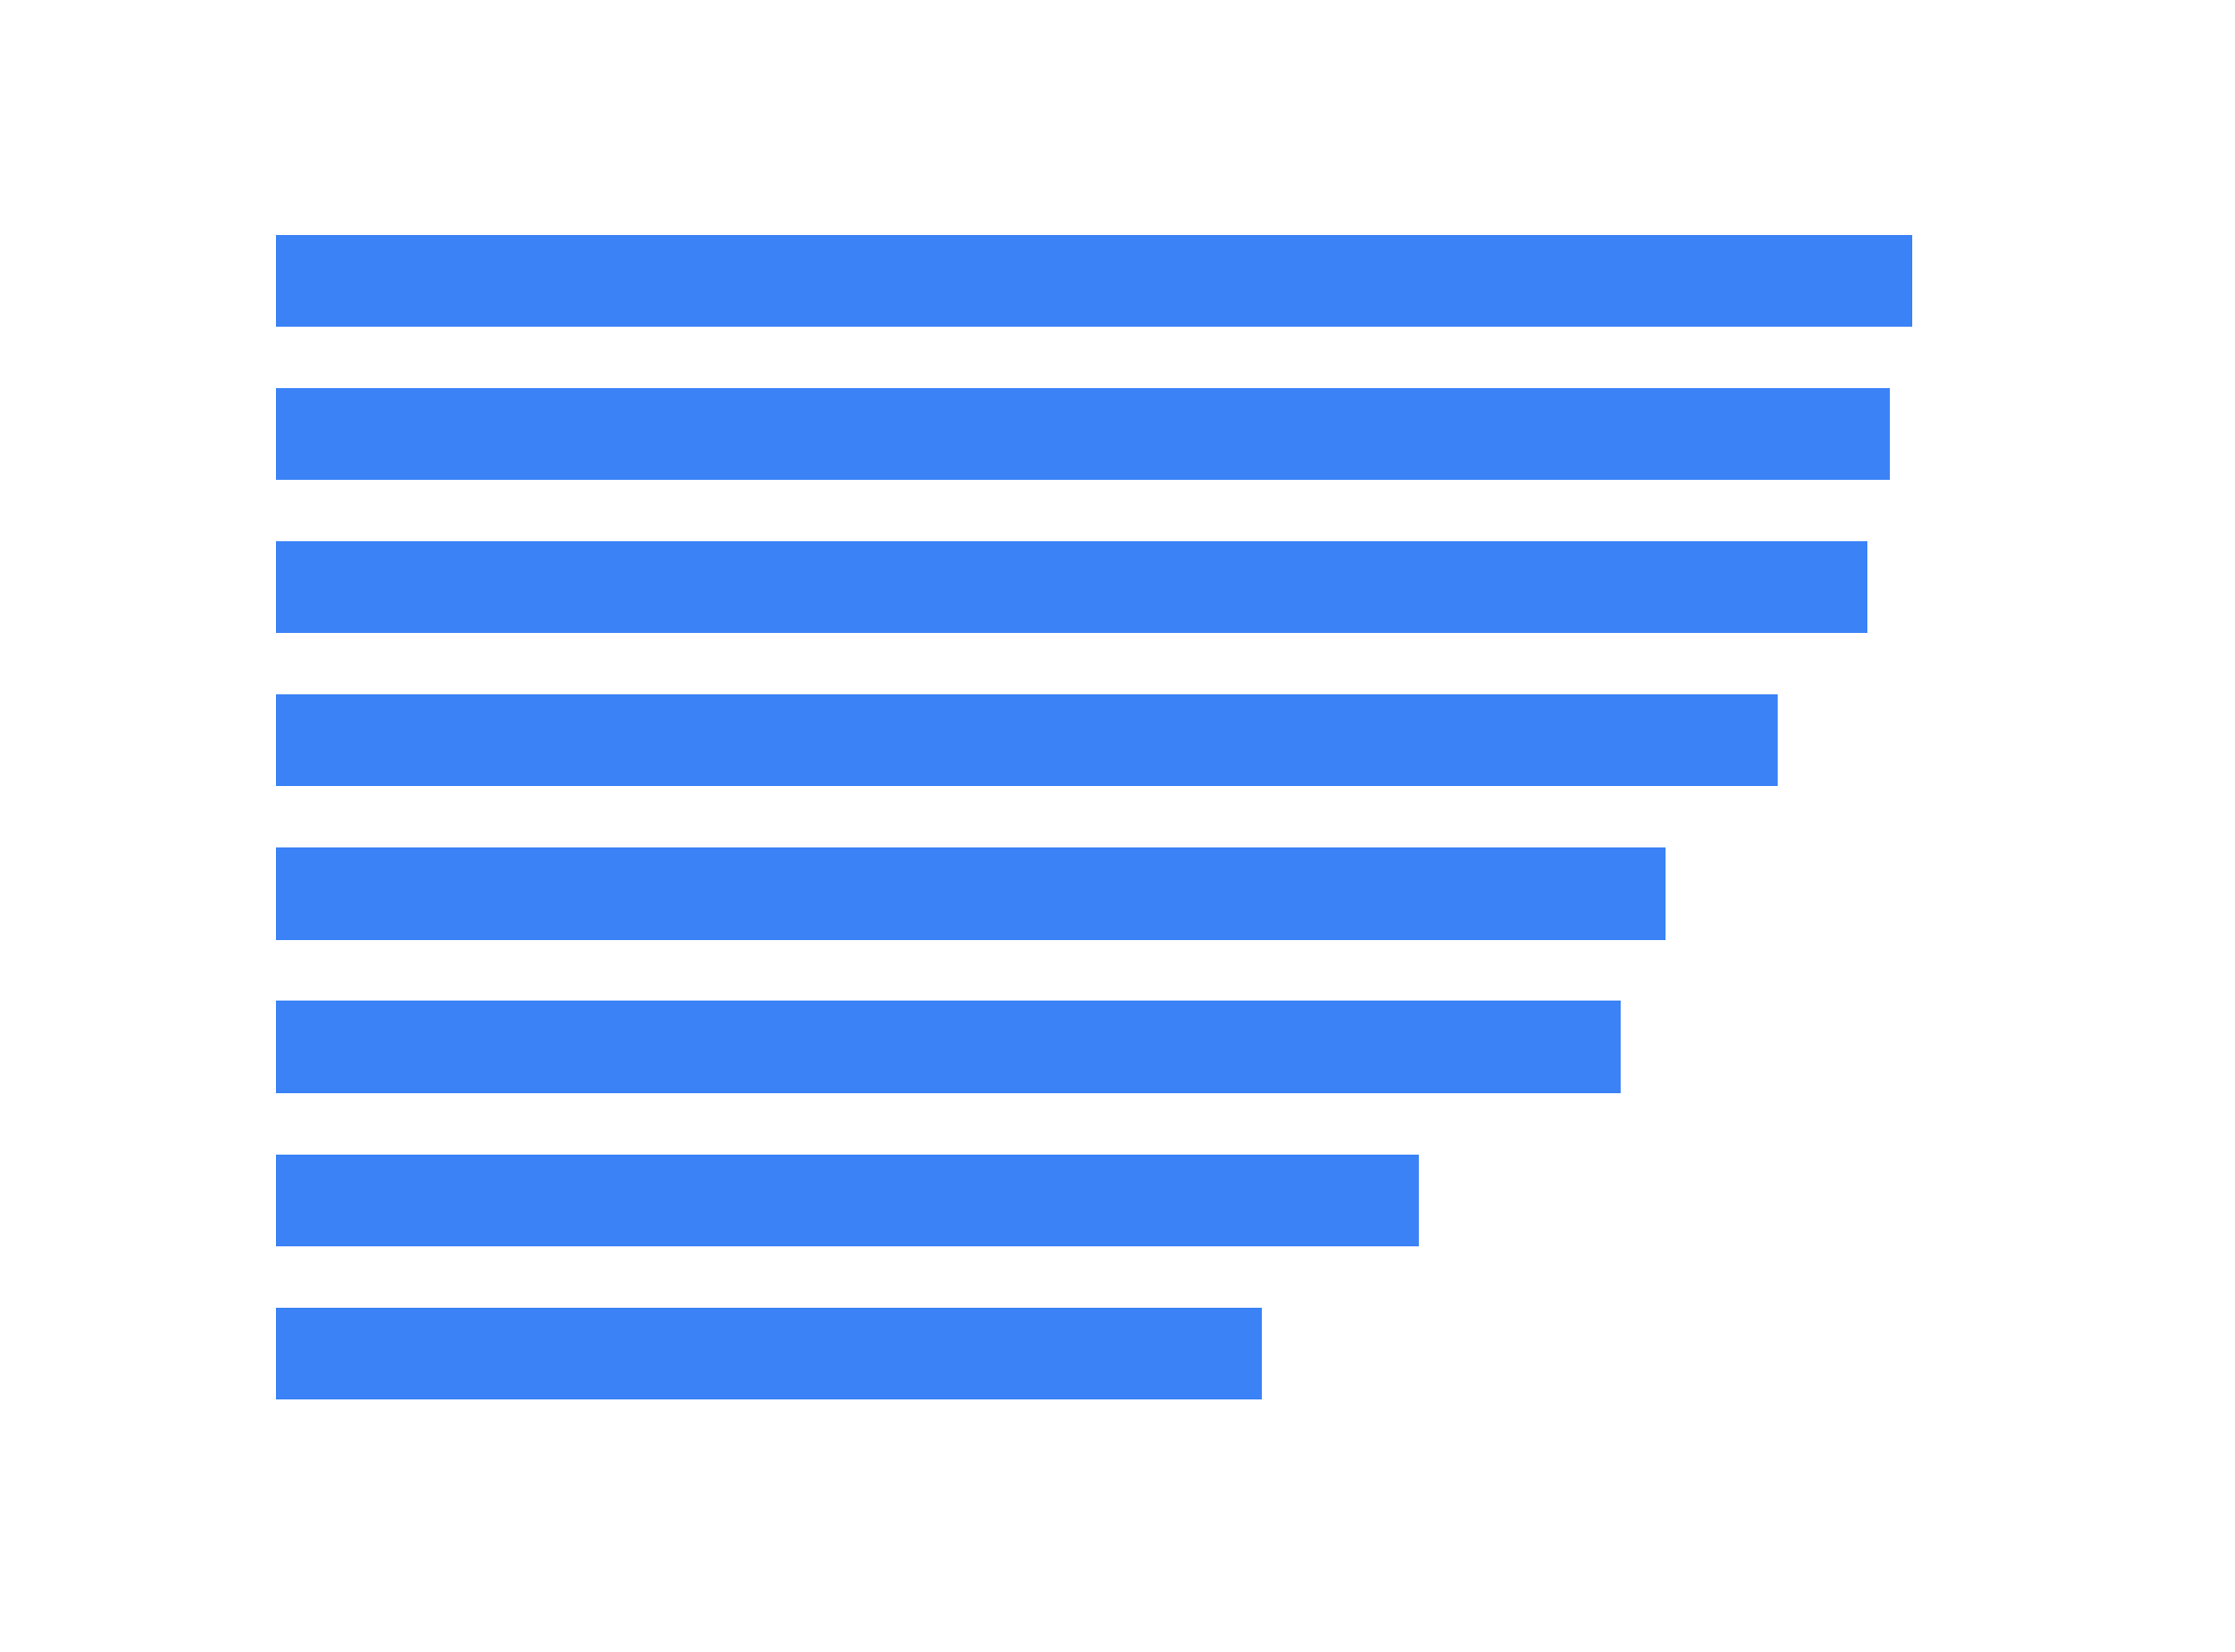

In [5]:
# 1. Configurar el lienzo transparente y de alta resolución
fig, ax = plt.subplots(figsize=(11, 6), facecolor="none", edgecolor="none", dpi=300)

# Extraer tus datos reales
top_paises = conteo_paises.head(15)

# 2. Dibujar las barras con un azul vibrante
bars = ax.barh(
    top_paises.index,
    top_paises.values,
    color="#3b82f6",  # Azul eléctrico (Gran contraste en modo oscuro)
    edgecolor="none",
    height=0.6,
)

# 3. Asignar márgenes amplios para que los nombres de los países no se corten a la izquierda
plt.subplots_adjust(left=0.28, right=0.88, top=0.88, bottom=0.15)

# 4. TÍTULOS Y ETIQUETAS EN COLOR BLANCO ENÉRGICO
ax.set_title(
    "Distribución de Ofertas Laborales por País de Procedencia",
    fontsize=14,
    pad=25,
    fontweight="bold",
    color="#ffffff",  # Título blanco
    loc="left",
)
ax.set_xlabel(
    "Cantidad de Ofertas Laborales", fontsize=11, labelpad=12, color="#ffffff"  # Etiqueta X blanca
)

# 5. SOLUCIÓN AL ERROR: Forzar que los textos de los ejes sean blancos
# Esto cambia el color de los nombres de los países (eje Y) y los números inferiores (eje X)
ax.tick_params(axis="both", colors="#ffffff", labelsize=11)
plt.setp(ax.get_xticklabels(), color="#ffffff")
plt.setp(ax.get_yticklabels(), color="#ffffff")

# Evitar desbordamientos en la derecha dando margen extra dinámico
ax.set_xlim(0, max(top_paises.values) * 1.18)

# Invertir el eje para mostrar el más alto arriba
ax.invert_yaxis()

# 6. Eliminar bordes negros de la caja de la gráfica
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

# 7. Agregar los números exactos al final de cada barra en color blanco
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + (max(top_paises.values) * 0.015),
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold",
        color="#ffffff",  # Valor de la barra blanco
    )

# 8. Cuadrícula vertical ultra sutil adaptada para modo oscuro
ax.grid(axis="x", linestyle=":", alpha=0.15, color="#ffffff")
ax.set_axisbelow(True)

# =======================================================
# 9. EXPORTACIÓN CON TRANSPARENCIA REAL
# =======================================================
"""plt.savefig(
    "distribucion_paises.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
    facecolor="none",
)"""

plt.show()

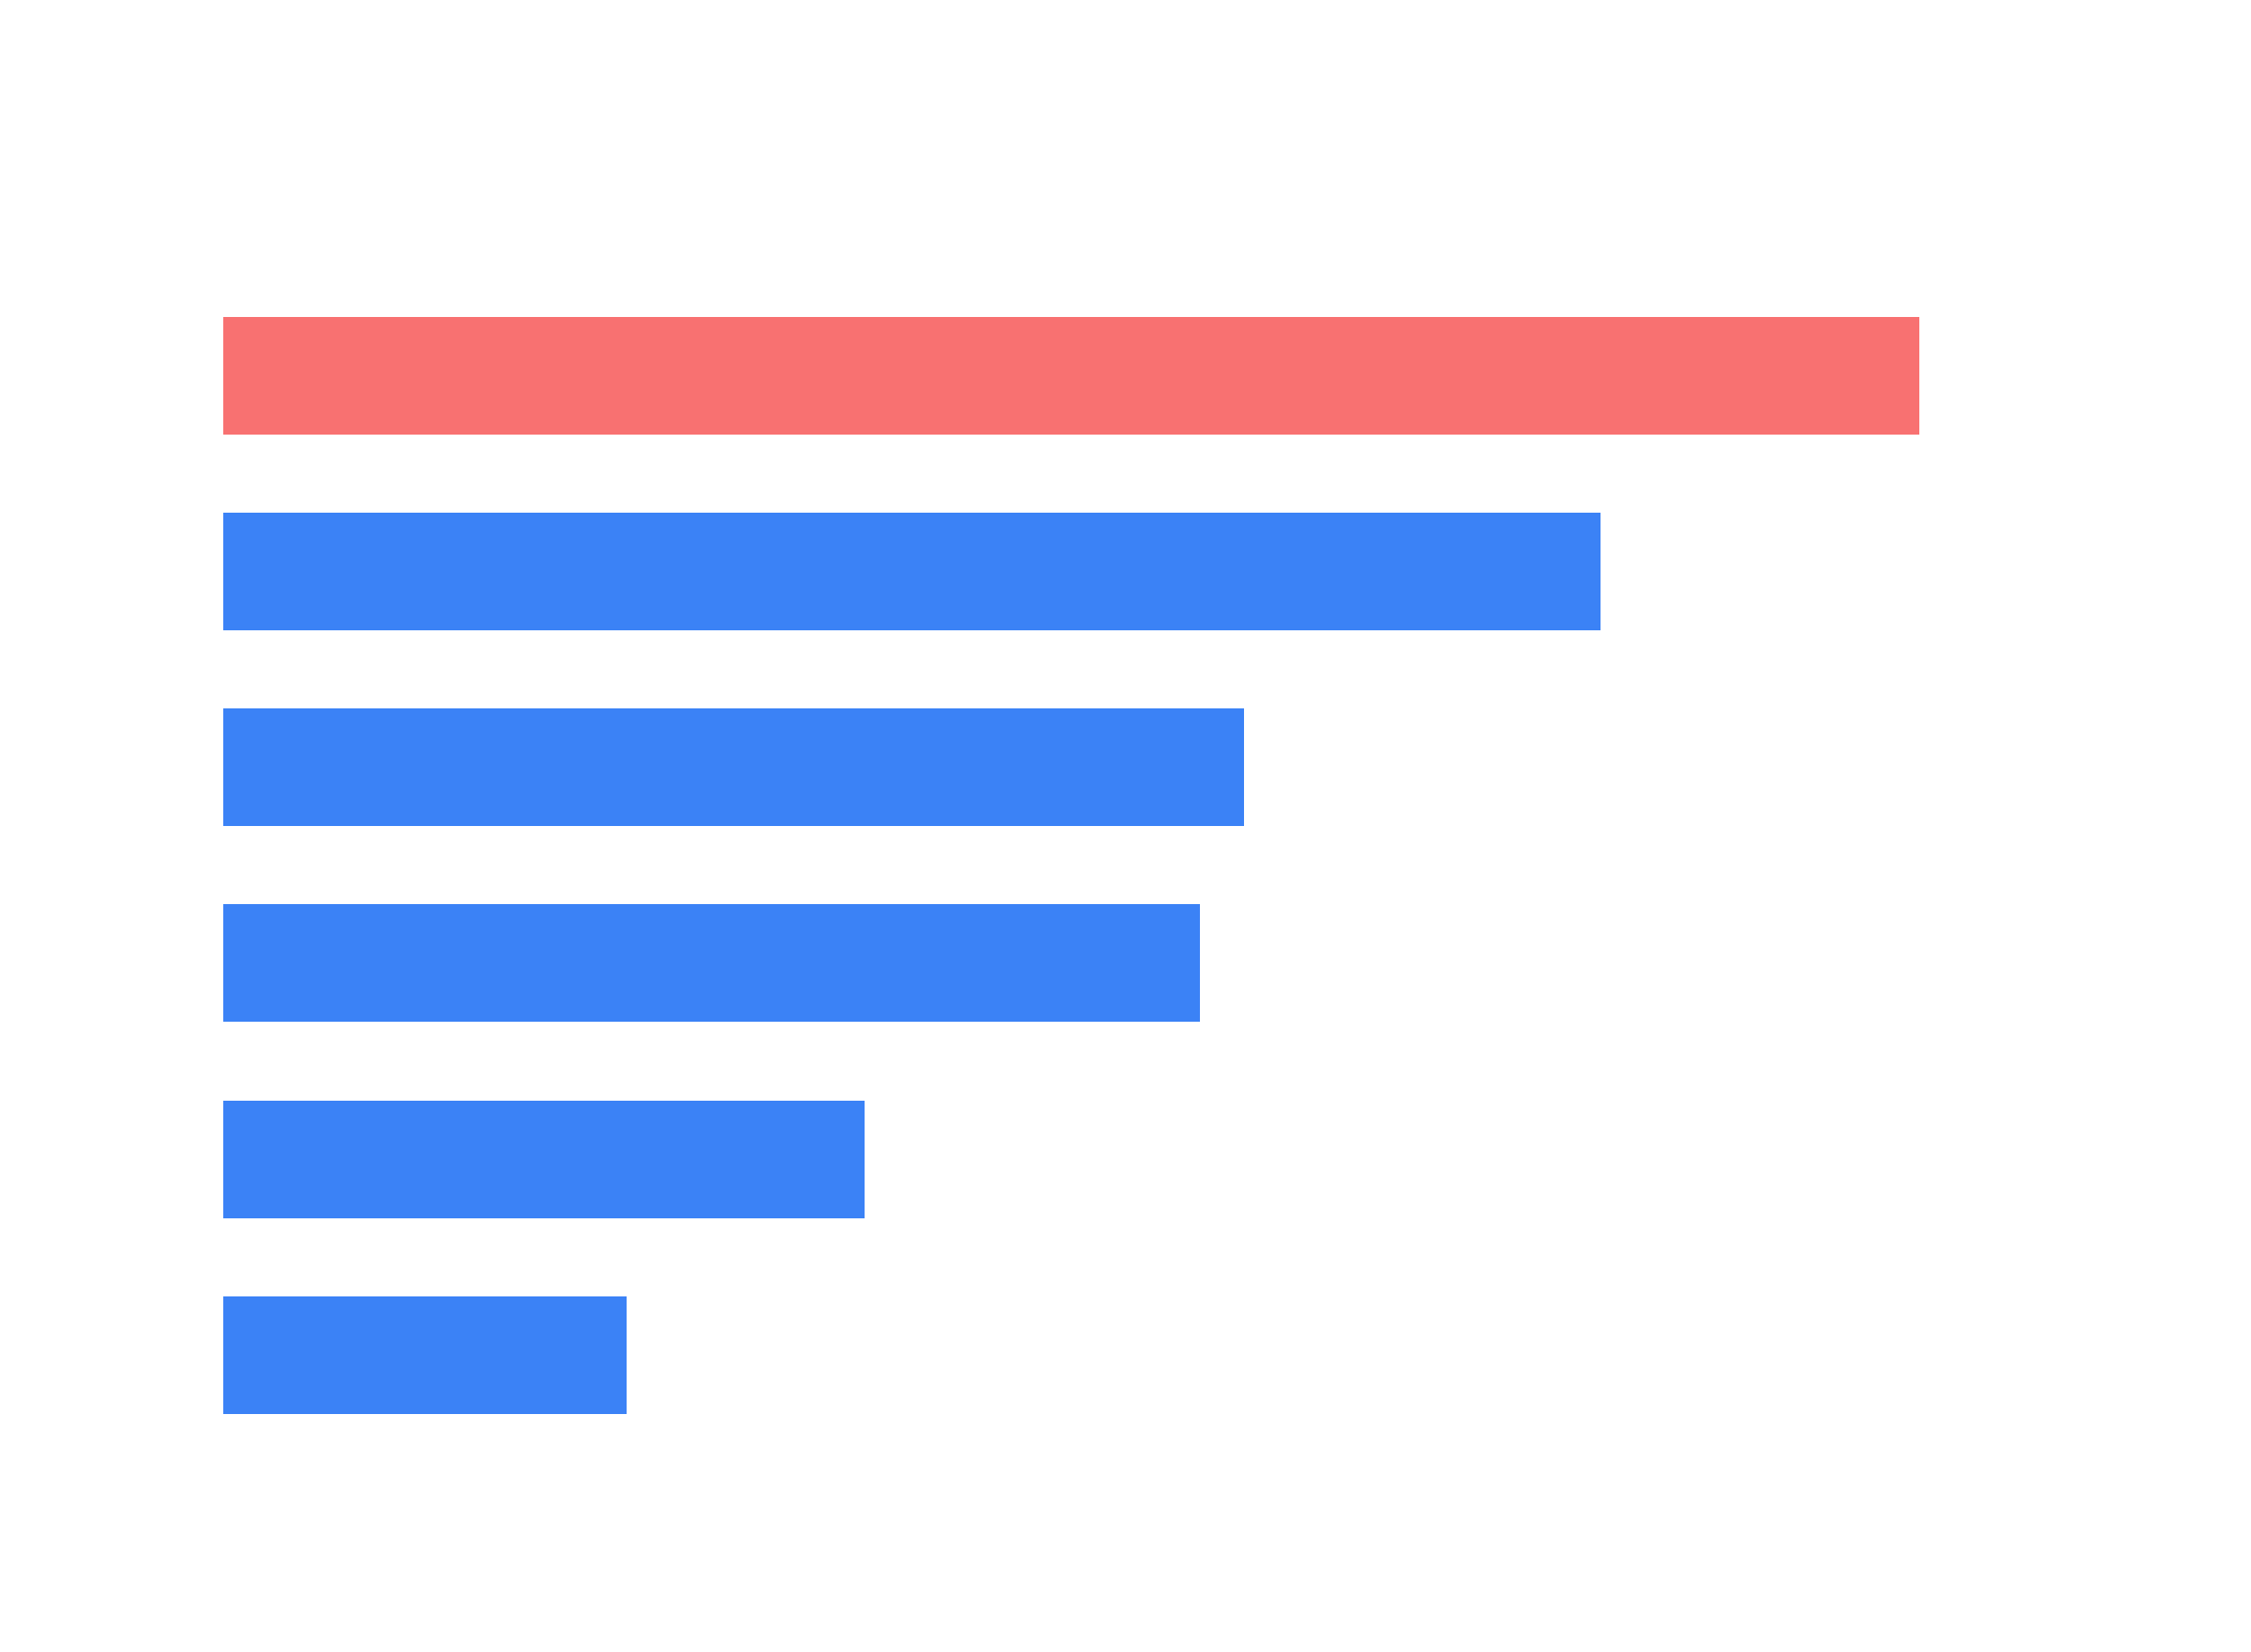

In [6]:
# 2. Definir las columnas de las herramientas
tecnologias = ["Python", "SQL", "Excel", "PowerBI", "Tableau", "R"]

# 3. Clonar temporalmente para transformar "Sí"/"No" en 1/0
df_binario = df.copy()
for col in tecnologias:
    df_binario[col] = df_binario[col].map({"Sí": 1, "No": 0})

# 4. Calcular la participación porcentual real
total_empresas = len(df_binario)
participacion = (df_binario[tecnologias].sum() / total_empresas) * 100
participacion = participacion.sort_values(ascending=True)

# =======================================================
# 5. DISEÑO DE ALTO IMPACTO PARA PORTAFOLIO OSCURO
# =======================================================
# Creamos el lienzo con ejes explícitos (ax) para controlar la transparencia
fig, ax = plt.subplots(figsize=(11, 6), facecolor="none", edgecolor="none", dpi=300)

# Colores adaptados para modo oscuro (Azul brillante estándar y Coral para destacar el líder)
colores = [
    "#3b82f6" if x < max(participacion.values) else "#f87171"
    for x in participacion.values
]

bars = ax.barh(
    participacion.index, participacion.values, color=colores, height=0.6
)

# Margen izquierdo seguro para que no se corten los nombres de las herramientas
plt.subplots_adjust(left=0.22, right=0.88, top=0.88, bottom=0.15)

# 6. Personalizar etiquetas y títulos en COLOR BLANCO
plt.title(
    "Distribución de Herramientas",
    fontsize=11,  # Reducido sutilmente para que entre completo
    fontweight="bold",
    color="#ffffff",
    pad=15,
    y=1.12,  # Lo elevamos para que no toque las columnas ampliadas
)

ax.set_xlabel(
    "Porcentaje de Empresas (%)", fontsize=11, labelpad=12, color="#ffffff"  # Texto X blanco
)

# Forzar que los textos y marcas de los ejes dejen de ser negros y pasen a ser blancos
ax.tick_params(axis="both", colors="#ffffff", labelsize=11)
plt.setp(ax.get_xticklabels(), color="#ffffff")
plt.setp(ax.get_yticklabels(), color="#ffffff")

# Espacio dinámico a la derecha para las etiquetas de los porcentajes
ax.set_xlim(0, max(participacion.values) * 1.18)

# Quitar bordes negros del recuadro
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

# 7. Imprimir los porcentajes al final de cada barra en COLOR BLANCO
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + (max(participacion.values) * 0.015),
        bar.get_y() + bar.get_height() / 2,
        f"{width:.0f}%",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold",
        color="#ffffff",  # Porcentaje blanco
    )

# 8. Cuadrícula vertical ultra sutil para fondos oscuros
ax.grid(axis="x", linestyle=":", alpha=0.15, color="#ffffff")
ax.set_axisbelow(True)

# =======================================================
# 9. EXPORTACIÓN CON TRANSPARENCIA REAL (¡NO CAMBIAR!)
# =======================================================
"""plt.savefig(
    "distribucion_herramientas.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
    facecolor="none",
) """

plt.show()


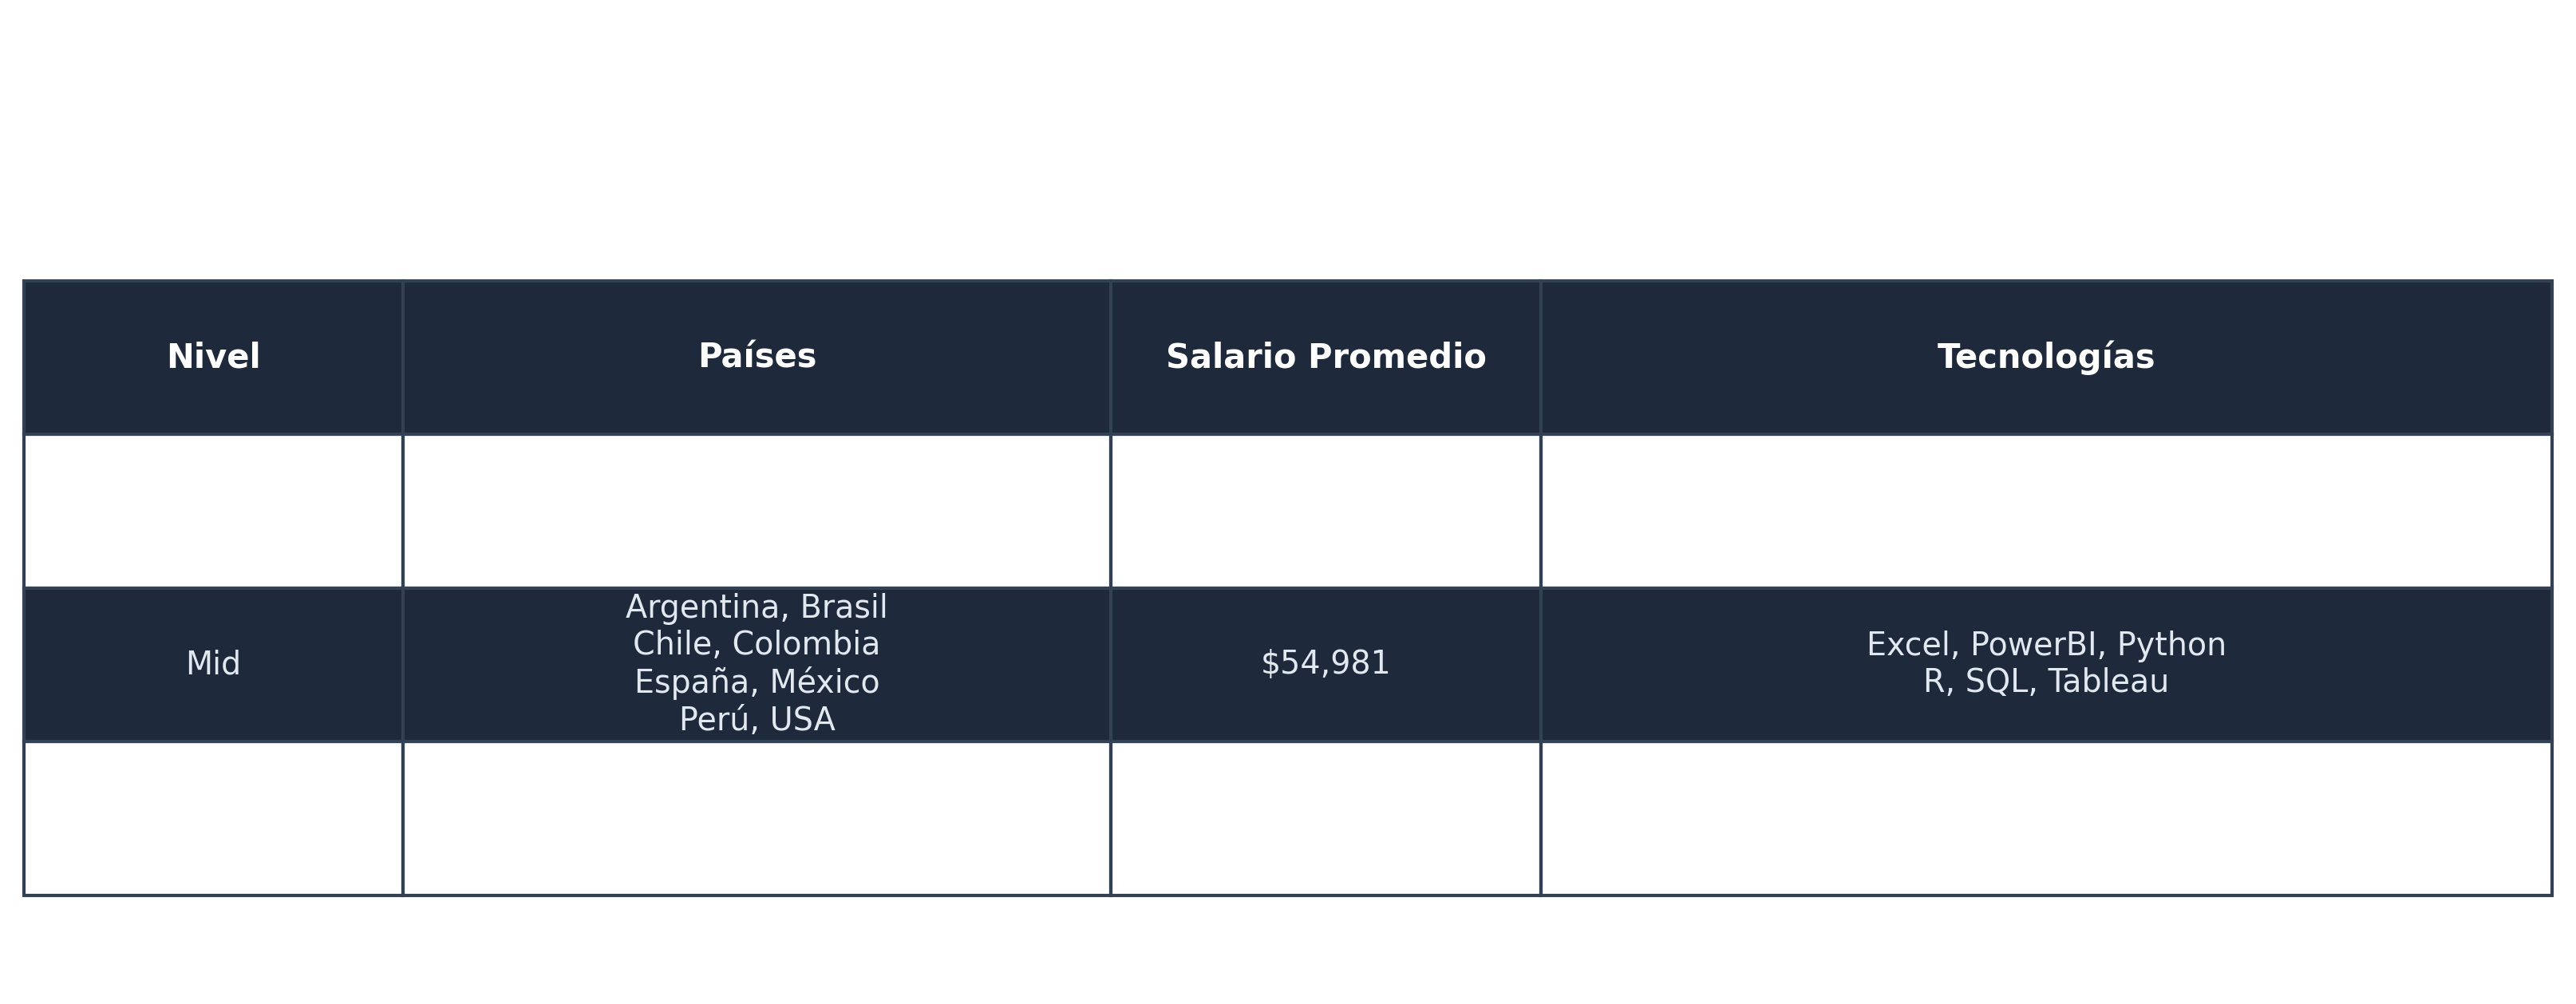

In [7]:
# 1. Extraer herramientas activas por cada fila
tecnologias = ["Python", "SQL", "Excel", "PowerBI", "Tableau", "R"]


def obtener_techs(row):
    return [t for t in tecnologias if row[t] == "Sí"]


df["Tech_List"] = df.apply(obtener_techs, axis=1)

# 2. AGRUPACIÓN: Separamos los Países en su propia columna para evitar que el texto se sature
resumen = df.groupby("Nivel").agg({
    "País": lambda x: ", ".join(sorted(list(set(x)))),  # Países en su columna limpia
    "Salario": "mean",
    "Tech_List": lambda x: ", ".join(
        sorted(list(set(sum(x, []))))
    ),  # Herramientas
}).reset_index()

# Ordenar los niveles de mayor a menor salario
resumen = resumen.sort_values(by="Salario", ascending=False)

# Formatear la columna de Salarios a dinero plano
resumen["Salario"] = resumen["Salario"].map("${:,.0f}".format)


# 3. CONTROL ANTIDESBORDAMIENTO (Saltos de línea en Países y Herramientas)
def formatear_texto_corto(texto, max_elementos=2):
    """Inserta salto de línea cada cierto número de elementos para que crezca verticalmente de forma ordenada."""
    elementos = [e.strip() for e in texto.split(",")]
    lineas = []
    for i in range(0, len(elementos), max_elementos):
        lineas.append(", ".join(elementos[i:i + max_elementos]))
    return "\n".join(lineas)


# Aplicamos el formateo vertical ordenado
resumen["País"] = resumen["País"].apply(
    lambda x: formatear_texto_corto(x, max_elementos=2)
)
resumen["Tech_List"] = resumen["Tech_List"].apply(
    lambda x: formatear_texto_corto(x, max_elementos=3)
)

# Renombrar las 4 columnas limpias
resumen.columns = ["Nivel", "Países", "Salario Promedio", "Tecnologías"]

# =======================================================
# 4. CONFIGURACIÓN DEL LIENZO SIMÉTRICO (Espacio Ampliado)
# =======================================================
# Ajustamos las dimensiones físicas de la imagen para que respire (11 de ancho x 4.2 de alto)
fig, ax = plt.subplots(
    figsize=(11, 4.2), facecolor="none", edgecolor="none", dpi=300
)
ax.axis("off")

# 5. Renderizar la tabla con las 4 columnas
tabla_grafica = ax.table(
    cellText=resumen.values, colLabels=resumen.columns, cellLoc="center", loc="center"
)

# =======================================================
# 6. ESTILIZACIÓN ULTRA-ESPACIADA (Evita encimado de textos)
# =======================================================
tabla_grafica.auto_set_font_size(False)
tabla_grafica.set_fontsize(9.5)

# CRUCIAL: Subimos el escalado a 3.8. Esto duplica la separación física entre filas
tabla_grafica.scale(1.0, 3.8)

# Repartimos el ancho de la tabla perfectamente (Suma 1.0 en total)
anchos_columnas = [0.15, 0.28, 0.17, 0.40]
for k, col_width in enumerate(anchos_columnas):
    for row in range(len(resumen) + 1):
        tabla_grafica[row, k].set_width(col_width)

# Aplicar colores y estilos para el modo oscuro del portafolio
for (row, col), cell in tabla_grafica.get_celld().items():
    if row == 0:
        # Encabezado oscuro premium
        cell.set_text_props(fontweight="bold", color="#ffffff", fontsize=10)
        cell.set_facecolor("#1e293b")
        cell.set_edgecolor("#334155")
    else:
        # Filas de datos adaptadas con alto contraste
        cell.set_edgecolor("#334155")
        if row % 2 == 0:
            cell.set_text_props(color="#e2e8f0")
            cell.set_facecolor("#1e293b")  # Fila par oscura
        else:
            cell.set_text_props(color="#ffffff")
            cell.set_facecolor("none")  # Fila impar transparente

# 7. TÍTULO CENTRADO CON TAMAÑO RE AJUSTADO PARA EVITAR CORTES
plt.title(
    "ANÁLISIS DE MERCADO POR NIVEL Y GEOGRAFÍA",
    fontsize=11,  # Reducido sutilmente para que entre completo
    fontweight="bold",
    color="#ffffff",
    pad=15,
    y=1.12,  # Lo elevamos para que no toque las columnas ampliadas
)

# Ajuste milimétrico de márgenes laterales
plt.subplots_adjust(left=0.02, right=0.98, top=0.80, bottom=0.02)

# =======================================================
# 8. EXPORTACIÓN EN ALTA RESOLUCIÓN TRANSPARENTE
# =======================================================
"""plt.savefig(
    "tabla-resumen.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
    facecolor="none",
)"""
plt.show()

## Conclusiones

El análisis evidencia que SQL es la herramienta más demandada, consolidándose como una habilidad esencial en el mercado laboral. Excel continúa siendo ampliamente utilizado, reflejando su importancia en procesos de análisis y reporte. Además, Python es más requerido en posiciones Junior dentro del dataset, aunque sigue presente en niveles Mid y Senior, lo que sugiere su relevancia para el crecimiento profesional. Finalmente, se observa una relación positiva entre experiencia y salario, indicando que el desarrollo de habilidades técnicas impacta directamente en la compensación.

El salario promedio mas alto lo podemos observar en los analistas de datos Senior en comparacion con los otros niveles.

Analisando oferta vs herramienta python podemos observar que el nivel Junior es quien mas requiere python como herramienta.